# 01 - Data Exploration

This notebook inspects the raw HCC1395 input data for the neoantigen prediction pipeline:
- **VCF**: VEP-annotated somatic mutations (`annotated.expression.vcf.gz`)
- **HLA typing**: OptiType output for patient HLA-I alleles
- **Expression & VAF**: read from tumour-sample FORMAT fields

## VCF structure notes

The VCF is a paired **tumour-normal** file with two samples:
`HCC1395_NORMAL_DNA` (index 0) and `HCC1395_TUMOR_DNA` (index 1).
VAF and RNA expression are stored as **FORMAT fields** on the tumour sample,
not inside the VEP CSQ string:

| FORMAT field | Content |
|---|---|
| `AF` | Tumour variant allele fraction (DNA) |
| `GX` | Gene-level expression: `GENE\|TPM` |
| `TX` | Transcript-level expression: `ENST\|TPM,...` (comma-separated) |
| `RDP` / `RAF` / `RAD` | RNA read depth / allele fraction / allelic depths |

The VEP CSQ field additionally carries two pVACtools plugin fields:
`WildtypeProtein` (full WT protein sequence) and `FrameshiftSequence`
(novel frameshifted sequence downstream of the variant).

## Why filter on VEP consequence rather than VCF variant type?

A VCF record describes a genomic event (SNV, insertion, deletion) via REF/ALT
alleles. But the same genomic event can have *different protein-level effects*
depending on the transcript. A 3bp deletion might be an inframe deletion in one
transcript and a frameshift in another (if it hits a splice junction). The VEP
consequence annotation is computed per-transcript and tells us the actual
protein-level effect, which is what matters for peptide generation. We therefore
filter on VEP consequence terms (e.g. `missense_variant`, `inframe_deletion`)
rather than on the genomic variant type.

In [1]:
import sys
from pathlib import Path

import cyvcf2
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path("../src").resolve()))

from neoantigen_pipeline.io.hla_reader import HLAReader
from neoantigen_pipeline.io.vcf_reader import (
    VCFReader,
    SUPPORTED_CONSEQUENCES,
    CONSEQUENCE_MISSENSE,
    CONSEQUENCE_FRAMESHIFT,
    CONSEQUENCE_INFRAME_DEL,
    CONSEQUENCE_INFRAME_INS,
)

sns.set_style("whitegrid")
matplotlib.rcParams["font.size"] = 12
matplotlib.rcParams["figure.figsize"] = (10, 6)
print("Imports OK")

Imports OK


In [2]:
DATA_DIR   = Path("../data/HCC1395_inputs")
VCF_PATH   = DATA_DIR / "annotated.expression.vcf.gz"
HLA_PATH   = DATA_DIR / "optitype_normal_result.tsv"

# The VCF has two samples: [NORMAL (0), TUMOR (1)].
# VCFReader needs to know the tumour index to read the right FORMAT values.
TUMOR_SAMPLE_INDEX = 1

for p in (VCF_PATH, HLA_PATH):
    print(f"{p.name}: exists={p.exists()}")

annotated.expression.vcf.gz: exists=True
optitype_normal_result.tsv: exists=True


## 1. HLA Typing

OptiType calls HLA class I alleles (A, B, C) from whole-exome or RNA-seq reads
aligned to an HLA reference. It does not call class II alleles (DP, DQ, DR),
which require separate tools (e.g. HLA-HD, arcasHLA). The class II alleles
listed below come from external genotyping data for HCC1395.

In [3]:
hla_df = pd.read_csv(str(HLA_PATH), sep="\t")
print("OptiType output:")
display(hla_df)

hla = HLAReader().read_optitype(str(HLA_PATH))
print("\nParsed HLA class-I alleles:")
for allele in hla.class_i_alleles:
    print(f"  {allele}")
print("\nKnown HLA class-II (manual, not in OptiType output):")
for allele in ("DQA1*03:03", "DQB1*03:02", "DRB1*04:05"):
    print(f"  {allele}")

OptiType output:


,Unnamed: 0,A1,A2,B1,B2,C1,C2,Reads,Objective
0,0,A*29:02,A*29:02,B*45:01,B*82:02,C*06:02,C*06:02,1748.0,1732.258



Parsed HLA class-I alleles:
  HLA-A*29:02
  HLA-B*45:01
  HLA-B*82:02
  HLA-C*06:02

Known HLA class-II (manual, not in OptiType output):
  DQA1*03:03
  DQB1*03:02
  DRB1*04:05


## 2. VCF Structure

Inspect sample names, FORMAT fields, and CSQ sub-field layout directly from
the VCF header before loading any records.

In [4]:
import re

with cyvcf2.VCF(str(VCF_PATH)) as vcf_raw:
    samples = vcf_raw.samples
    tumor_name = vcf_raw.samples[TUMOR_SAMPLE_INDEX]

    # Collect FORMAT header lines.
    # cyvcf2's header_iter().info() returns a dict; the reliable way to
    # identify FORMAT headers is via the "HeaderType" key, NOT by checking
    # whether the raw header string starts with "##FORMAT".  The raw string
    # approach fails for some cyvcf2 versions where str(h) may not reproduce
    # the original header line verbatim.
    fmt_fields = []
    for h in vcf_raw.header_iter():
        info = h.info(extra=True)
        if info.get("HeaderType") == "FORMAT" and info.get("ID"):
            fmt_fields.append((info["ID"], info.get("Description", "")[:80]))
        del info

    csq_fields = []
    for h in vcf_raw.header_iter():
        info = h.info(extra=True)
        if info.get("ID") == "CSQ":
            desc = info.get("Description", "")
            m = re.search(r"Format: (.+?)(?:\"|'|$)", desc)
            if m:
                csq_fields = m.group(1).strip().split("|")
        del info
    del h  # release C-backed header object before VCF closes

print("Samples:", samples)
print(f"Tumour sample index: {TUMOR_SAMPLE_INDEX} -> '{tumor_name}'")

print("\nFORMAT fields:")
for fid, fdesc in fmt_fields:
    print(f"  {fid:12s}  {fdesc[:70]}")

highlight = {"HGVSp", "HGVSc", "SYMBOL", "Feature", "Consequence",
             "Amino_acids", "WildtypeProtein", "FrameshiftSequence"}
if csq_fields:
    print(f"\nCSQ sub-fields (VEP annotation):")
    print(f"  Total CSQ sub-fields: {len(csq_fields)}")
    for i, f in enumerate(csq_fields):
        if f in highlight:
            print(f"  [{i:2d}] {f}")

Samples: ['HCC1395_NORMAL_DNA', 'HCC1395_TUMOR_DNA']
Tumour sample index: 1 -> 'HCC1395_TUMOR_DNA'

FORMAT fields:
  AD            "Allelic depths for the ref and alt alleles in the order listed"
  AF            "Variant-allele frequency for the alt alleles"
  AU            "Number of 'A' alleles used in tiers 1,2"
  BCN50         "Fraction of filtered reads within 50 bases of the indel."
  CU            "Number of 'C' alleles used in tiers 1,2"
  DP            "Read depth"
  DP2           "Read depth for tier2"
  DP4           "Strand read counts: ref/fwd, ref/rev, var/fwd, var/rev"
  DP50          "Average tier1 read depth within 50 bases"
  F1R2          "Count of reads in F1R2 pair orientation supporting each allele"
  F2R1          "Count of reads in F2R1 pair orientation supporting each allele"
  FAD           "Count of fragments supporting each allele."
  FDP           "Number of basecalls filtered from original read depth for tier1"
  FDP50         "Average tier1 number of base

## 3. Variant Loading and Overview

### Records vs annotations

A single VCF record describes one genomic variant. VEP annotates it against
every overlapping transcript, producing one CSQ entry per transcript. The
VCFReader emits one `SomaticVariant` per supported CSQ entry. So if a record
overlaps 3 coding transcripts and has a missense consequence in each, it
produces 3 `SomaticVariant` objects.

`len(all_variants)` therefore counts **annotations** (transcript-level), not
VCF records. The raw record count is computed separately below for bookkeeping.

In [5]:
# Load all supported variant types via the pipeline reader.
# tumor_sample_index=1 ensures VAF and expression are read from the tumour sample.
reader = VCFReader(str(VCF_PATH), tumor_sample_index=TUMOR_SAMPLE_INDEX)
all_variants = reader.read_variants()  # missense + inframe indels + frameshifts
missense_variants = [v for v in all_variants if v.variant_type == "missense"]

# Count all records and consequence types via raw cyvcf2 for comparison.
# We scan ALL CSQ entries per record (not just entries[0]) to get accurate
# per-consequence counts at the annotation level.  The first entry is often a
# non-coding transcript (e.g. intron_variant) even when later entries carry the
# missense annotation we actually care about.
total_records = 0
csq_counts: dict[str, int] = {}
with cyvcf2.VCF(str(VCF_PATH)) as vcf_raw:
    record = None
    for record in vcf_raw:
        total_records += 1
        csq_val = record.INFO.get("CSQ")
        if csq_val is not None:
            entries = csq_val.split(",") if isinstance(csq_val, str) else list(csq_val)
            for entry in entries:
                csq_str = entry.split("|")[1] if "|" in entry else ""
                for term in csq_str.split("&"):
                    if term:
                        csq_counts[term] = csq_counts.get(term, 0) + 1
    del record

print(f"Total VCF records          : {total_records}")
print(f"Supported variants loaded  : {len(all_variants)}")
print(f"  missense                 : {sum(1 for v in all_variants if v.variant_type == 'missense')}")
print(f"  inframe_deletion         : {sum(1 for v in all_variants if v.variant_type == 'inframe_deletion')}")
print(f"  inframe_insertion        : {sum(1 for v in all_variants if v.variant_type == 'inframe_insertion')}")
print(f"  frameshift               : {sum(1 for v in all_variants if v.variant_type == 'frameshift')}")

print("\nVEP consequence counts (all annotations across all records):")
csq_series = pd.Series(csq_counts).sort_values(ascending=False)
print(csq_series.head(20).to_string())

Total VCF records          : 1470
Supported variants loaded  : 1209
  missense                 : 1133
  inframe_deletion         : 29
  inframe_insertion        : 3
  frameshift               : 44

VEP consequence counts (all annotations across all records):
intron_variant                         5310
downstream_gene_variant                2488
upstream_gene_variant                  1733
non_coding_transcript_variant          1324
NMD_transcript_variant                 1168
missense_variant                       1133
non_coding_transcript_exon_variant      740
regulatory_region_variant               446
3_prime_UTR_variant                     439
synonymous_variant                      385
splice_polypyrimidine_tract_variant     225
splice_region_variant                   187
5_prime_UTR_variant                     161
TF_binding_site_variant                 151
splice_acceptor_variant                 111
stop_gained                              50
frameshift_variant                   

### 3.1 Excluded variant consequences

A VCF record is "truly excluded" when **none** of its CSQ entries have a
consequence in `SUPPORTED_CONSEQUENCES`. This is the right definition because
VEP lists one CSQ entry per overlapping transcript, and the first one is often
a non-coding annotation (e.g. `intron_variant` or `downstream_gene_variant`).
The pipeline scans all entries, so a record that is `intron_variant` in one
transcript but `missense_variant` in another is correctly retained.

The main excluded categories and their biological meaning:

- **synonymous_variant**: The nucleotide change does not alter the amino acid.
  No novel peptide is produced, so there is no neoantigen.
- **intron_variant / upstream/downstream_gene_variant**: The variant falls
  outside coding exons for all annotated transcripts. No protein change.
- **splice_region_variant** (without a co-occurring coding consequence): Sits
  near a splice site but VEP does not predict an altered protein product. Some
  of these may in reality cause mis-splicing and novel junctions, but predicting
  that requires specialised splice-effect tools (e.g. SpliceAI) and is outside
  the scope of this pipeline.
- **stop_gained**: Introduces a premature stop codon. The truncated protein
  *could* produce novel junction peptides, but the current pipeline does not
  handle this variant type. This is a known limitation (see project summary).

In [6]:
# Count truly excluded records and their dominant consequence terms.
truly_excluded_consequences: dict[str, int] = {}
n_truly_excluded = 0
n_supported_records = 0

with cyvcf2.VCF(str(VCF_PATH)) as vcf_scan:
    vcf_record = None
    for vcf_record in vcf_scan:
        csq_val = vcf_record.INFO.get("CSQ")
        if csq_val is None:
            n_truly_excluded += 1
            truly_excluded_consequences["(no CSQ)"] = (
                truly_excluded_consequences.get("(no CSQ)", 0) + 1
            )
            continue

        entries = csq_val.split(",") if isinstance(csq_val, str) else list(csq_val)
        # Collect all consequence terms across ALL CSQ entries for this record
        all_terms: list[str] = []
        for entry in entries:
            csq_consequence = entry.split("|")[1] if "|" in entry else ""
            all_terms.extend(csq_consequence.split("&"))

        has_supported = any(t in SUPPORTED_CONSEQUENCES for t in all_terms)
        if has_supported:
            n_supported_records += 1
        else:
            n_truly_excluded += 1
            for term in all_terms:
                if term and term not in SUPPORTED_CONSEQUENCES:
                    truly_excluded_consequences[term] = (
                        truly_excluded_consequences.get(term, 0) + 1
                    )
    del vcf_record

excluded_series = pd.Series(truly_excluded_consequences).sort_values(ascending=False)

print(f"Total VCF records       : {total_records}")
print(f"Supported records       : {n_supported_records}")
print(f"  (variant annotations) : {len(all_variants)}  [multiple transcripts per record]")
print(f"Truly excluded records  : {n_truly_excluded}")
print(f"  Check                 : {n_supported_records} + {n_truly_excluded} = {n_supported_records + n_truly_excluded}")
print()
print("Dominant excluded VEP consequence types")
print("(each excluded record may contribute multiple terms):")
display(
    excluded_series.rename("term_count")
    .to_frame()
    .assign(pct_of_excluded=lambda x: (100 * x["term_count"] / n_truly_excluded).round(1))
)

Total VCF records       : 1470
Supported records       : 367
  (variant annotations) : 1209  [multiple transcripts per record]
Truly excluded records  : 1103
  Check                 : 367 + 1103 = 1470

Dominant excluded VEP consequence types
(each excluded record may contribute multiple terms):


,term_count,pct_of_excluded
intron_variant,5059,458.7
downstream_gene_variant,1914,173.5
upstream_gene_variant,1364,123.7
non_coding_transcript_variant,1224,111.0
NMD_transcript_variant,910,82.5
non_coding_transcript_exon_variant,395,35.8
synonymous_variant,384,34.8
regulatory_region_variant,360,32.6
3_prime_UTR_variant,291,26.4
splice_polypyrimidine_tract_variant,224,20.3


### 3.2 Known limitations in variant loading

A few variant types that *could* produce neoantigens are not yet handled:

1. **Frameshifts**: Only 1 of ~15 frameshift records is loaded. The HGVSp regex
   does not handle `Ter` notation (e.g. `p.Val600GlyfsTer12`), immediate stops,
   or `p.?` (unknown protein consequence). This is a known bug.
2. **stop_gained** (16 records): Premature stop codons produce truncated proteins.
   The junction peptide spanning the novel stop could be immunogenic but is not
   currently modelled.
3. **Inframe indels**: Reference validation against the proteome currently checks
   only a single residue for multi-residue deletions, producing spurious warnings.
   The mutant protein construction also only handles single-residue substitution
   logic and needs separate deletion/insertion paths.

In [7]:
# Build a DataFrame from all supported variants for downstream analysis
rows = []
for v in all_variants:
    rows.append({
        "chrom"         : v.chrom,
        "pos"           : v.pos,
        "gene"          : v.gene,
        "transcript_id" : v.transcript_id,
        "protein_change": v.protein_change,
        "variant_type"  : v.variant_type,
        "aa_pos"        : v.aa_pos,
        "vaf"           : v.vaf,
        "expression_tpm": v.expression,
        "is_frameshift" : v.is_frameshift,
    })

df = pd.DataFrame(rows)
print(f"DataFrame shape: {df.shape}")
print(f"\nVariant type counts:")
print(df["variant_type"].value_counts().to_string())
print(f"\nExpression data coverage: {df['expression_tpm'].notna().sum()}/{len(df)} variants")
print(f"  Expression = 0 TPM : {(df['expression_tpm'] == 0).sum()}")
print(f"  Expression > 0 TPM : {(df['expression_tpm'] > 0).sum()}")
print(f"\nVAF summary (tumour sample):")
print(df["vaf"].describe().round(3).to_string())
print(f"\nFirst 5 rows:")
display(df.head())

DataFrame shape: (1209, 10)

Variant type counts:
variant_type
missense             1133
frameshift             44
inframe_deletion       29
inframe_insertion       3

Expression data coverage: 1209/1209 variants
  Expression = 0 TPM : 394
  Expression > 0 TPM : 815

VAF summary (tumour sample):
count    1209.000
mean        0.502
std         0.309
min         0.050
25%         0.250
50%         0.418
75%         0.724
max         1.000

First 5 rows:


,chrom,pos,gene,transcript_id,protein_change,variant_type,aa_pos,vaf,expression_tpm,is_frameshift
0,chr1,451649,OR4F29,ENST00000426406.4,p.Glu11Ter,frameshift,11,0.12146,0.00000,True
1,chr1,686483,OR4F16,ENST00000332831.5,p.Pro58Ala,missense,58,0.12783,0.00000,False
2,chr1,13318694,PRAMEF15,ENST00000376152.2,p.Arg96His,missense,96,0.09825,0.00000,False
3,chr1,16006134,SRARP,ENST00000329454.2,p.Gly100Trp,missense,100,1.00000,0.08199,False
4,chr1,16972418,CROCC,ENST00000375541.10,p.Ser2009Cys,missense,2009,0.98824,2.14688,False


## 4. Visualisations

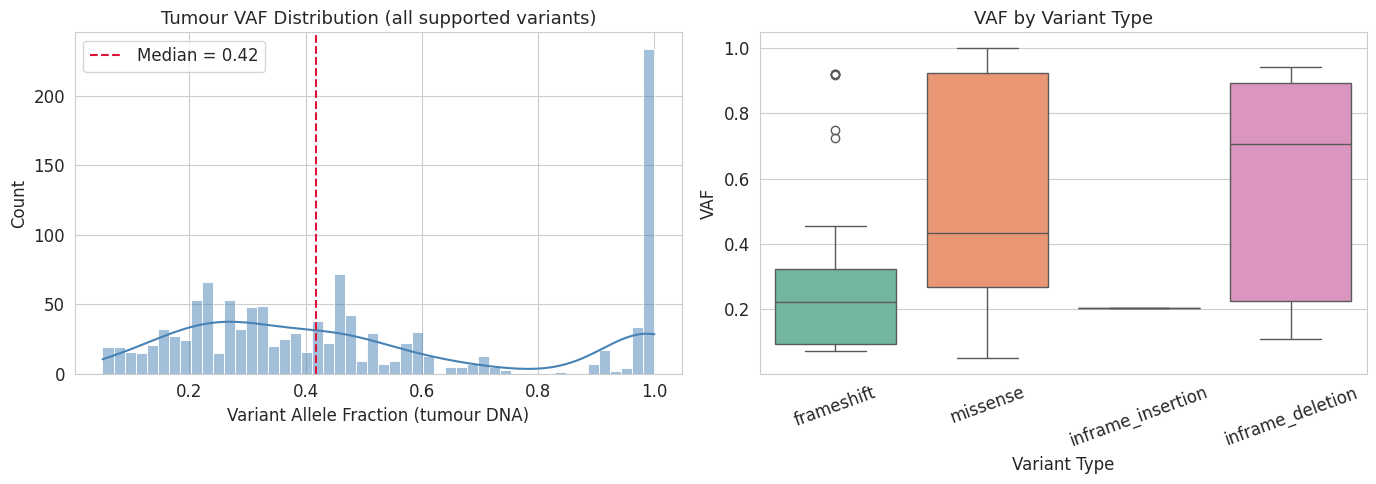

VAF: min=0.050, median=0.418, max=1.000


In [8]:
# -- Plot 1: VAF distribution (tumour sample)
vaf_data = df["vaf"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: full histogram
sns.histplot(vaf_data, bins=50, kde=True, color="steelblue", ax=axes[0])
axes[0].axvline(vaf_data.median(), color="crimson", linestyle="--",
                label=f"Median = {vaf_data.median():.2f}")
axes[0].set_title("Tumour VAF Distribution (all supported variants)", fontsize=13)
axes[0].set_xlabel("Variant Allele Fraction (tumour DNA)")
axes[0].set_ylabel("Count")
axes[0].legend()

# Right: VAF by variant type
df_vaf = df[["vaf", "variant_type"]].copy()
sns.boxplot(data=df_vaf, x="variant_type", y="vaf", hue="variant_type",
            palette="Set2", legend=False, ax=axes[1])
axes[1].set_title("VAF by Variant Type", fontsize=13)
axes[1].set_xlabel("Variant Type")
axes[1].set_ylabel("VAF")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

print(f"VAF: min={vaf_data.min():.3f}, "
      f"median={vaf_data.median():.3f}, "
      f"max={vaf_data.max():.3f}")

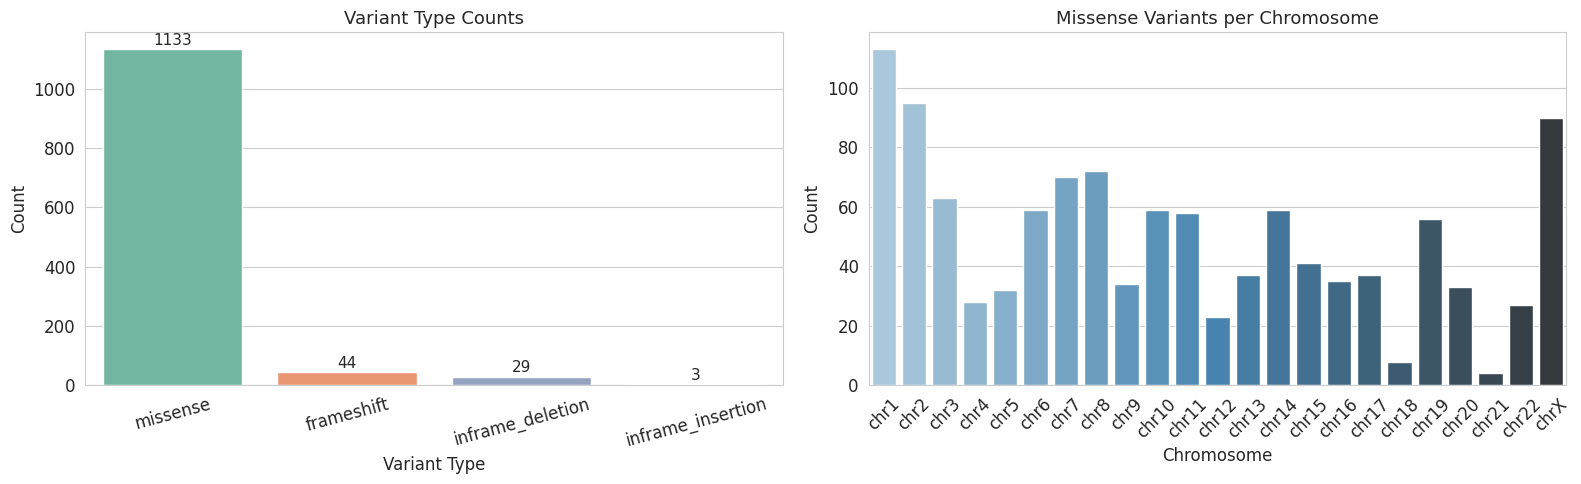

In [9]:
# -- Plot 2: Variant type histogram and chromosomal distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: variant type bar chart
type_counts = df["variant_type"].value_counts()
sns.barplot(x=type_counts.index, y=type_counts.values, hue=type_counts.index,
            palette="Set2", legend=False, ax=axes[0])
axes[0].set_title("Variant Type Counts", fontsize=13)
axes[0].set_xlabel("Variant Type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=15)
for bar, val in zip(axes[0].patches, type_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 5, str(val),
                 ha="center", va="bottom", fontsize=11)

# Right: per-chromosome missense count
chrom_counts = df[df["variant_type"] == "missense"]["chrom"].value_counts()

def _chrom_key(c: str) -> tuple:
    c = c.lstrip("chr")
    try:
        return (0, int(c))
    except ValueError:
        return (1, c)

sorted_chroms = sorted(chrom_counts.index, key=_chrom_key)
chrom_counts = chrom_counts.loc[sorted_chroms]

sns.barplot(x=chrom_counts.index.astype(str), y=chrom_counts.values,
            hue=chrom_counts.index.astype(str), palette="Blues_d", legend=False, ax=axes[1])
axes[1].set_title("Missense Variants per Chromosome", fontsize=13)
axes[1].set_xlabel("Chromosome")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

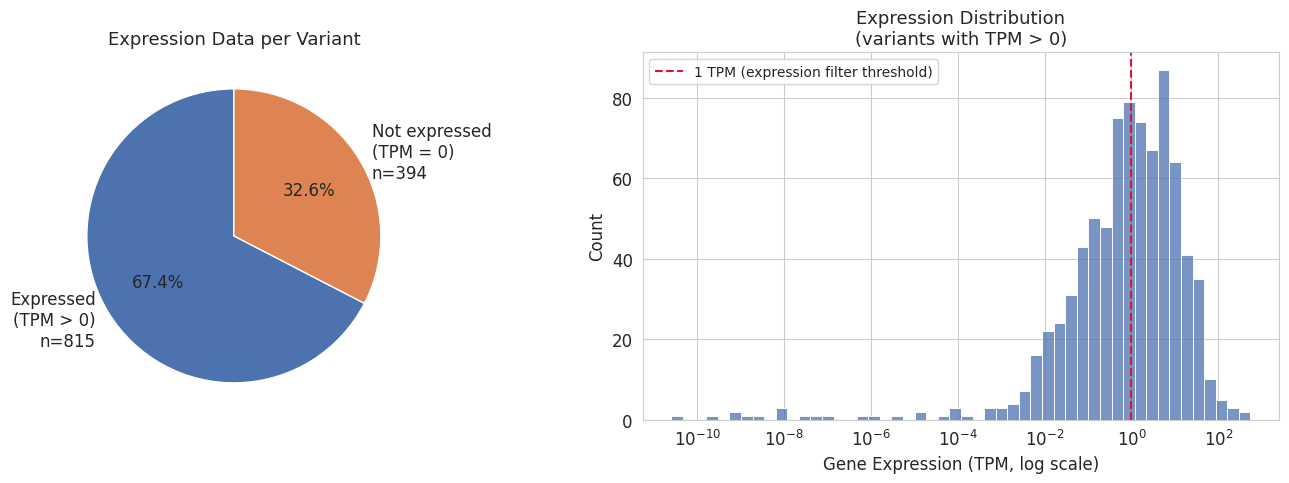

Expression coverage: 1209/1209 variants have TX/GX data
  Expressed (TPM > 0) : 815 (67.4%)
  Not expressed       : 394 (32.6%)
  TPM range (>0)      : 0.000 - 549.9


In [10]:
# -- Plot 3: Expression data
expr = df["expression_tpm"].dropna()
n_zero  = (expr == 0).sum()
n_pos   = (expr > 0).sum()
n_total = len(expr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: expression availability breakdown
labels = [
    f"Expressed\n(TPM > 0)\nn={n_pos}",
    f"Not expressed\n(TPM = 0)\nn={n_zero}",
    f"No expression data\nn={len(df) - n_total}",
]
sizes = [n_pos, n_zero, len(df) - n_total]
colors = ["#4C72B0", "#DD8452", "#aaaaaa"]
# Remove slices with zero count
labels_f = [l for l, s in zip(labels, sizes) if s > 0]
colors_f = [c for c, s in zip(colors, sizes) if s > 0]
sizes_f  = [s for s in sizes if s > 0]
axes[0].pie(sizes_f, labels=labels_f, colors=colors_f,
            autopct="%1.1f%%", startangle=90)
axes[0].set_title("Expression Data per Variant", fontsize=13)

# Right: distribution of expressed variants (log scale x)
expr_pos = expr[expr > 0]
sns.histplot(expr_pos, bins=50, log_scale=True, color="#4C72B0", ax=axes[1])
axes[1].axvline(1.0, color="crimson", linestyle="--",
                label="1 TPM (expression filter threshold)")
axes[1].set_title("Expression Distribution\n(variants with TPM > 0)", fontsize=13)
axes[1].set_xlabel("Gene Expression (TPM, log scale)")
axes[1].set_ylabel("Count")
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"Expression coverage: {n_total}/{len(df)} variants have TX/GX data")
print(f"  Expressed (TPM > 0) : {n_pos} ({100*n_pos/n_total:.1f}%)")
print(f"  Not expressed       : {n_zero} ({100*n_zero/n_total:.1f}%)")
print(f"  TPM range (>0)      : {expr_pos.min():.3f} - {expr_pos.max():.1f}")

### VAF vs Expression

The scatter below shows expressed missense variants coloured by a rough clonality
threshold (VAF > 0.4). This threshold is a simple heuristic: in a diploid tumour
region with ~50% tumour purity, a clonal heterozygous mutation would appear at
VAF ~ 0.5. The actual relationship between VAF and clonality depends on tumour
purity, ploidy, and copy number state, none of which are modelled here.

For neoantigen prioritisation, high-VAF + high-expression variants are the most
promising candidates because they are present in a large fraction of tumour cells
and the gene is actively transcribed.

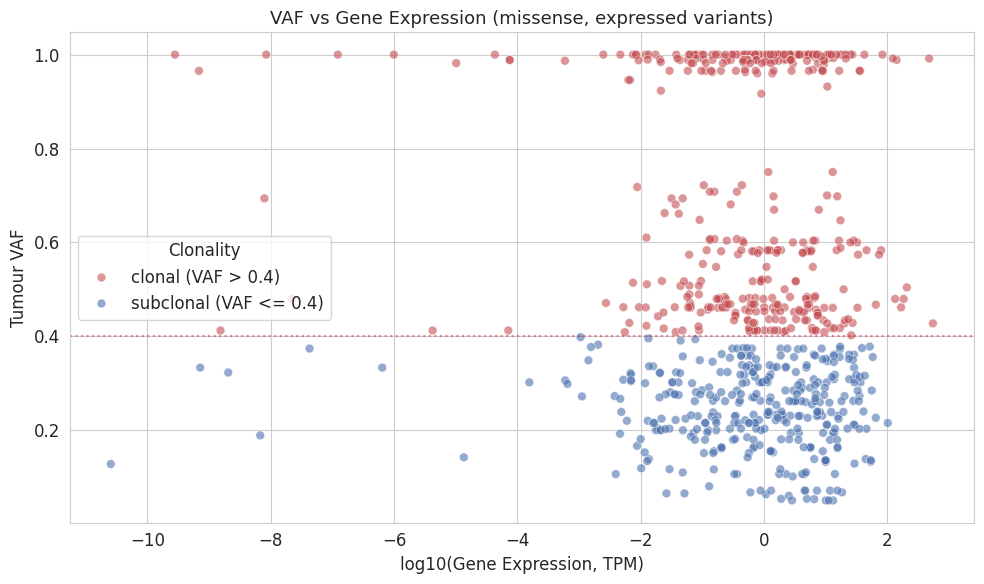

Expressed missense variants: 763
  Clonal (VAF > 0.4): 412
  Subclonal:          351


In [11]:
# -- Plot 4: VAF vs expression scatter for expressed variants
df_exp = df[(df["expression_tpm"] > 0) & (df["variant_type"] == "missense")].copy()
df_exp["log10_expr"] = np.log10(df_exp["expression_tpm"])

df_exp["clonality"] = df_exp["vaf"].apply(
    lambda v: "clonal (VAF > 0.4)" if v > 0.4 else "subclonal (VAF <= 0.4)"
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=df_exp, x="log10_expr", y="vaf",
    hue="clonality", palette={"clonal (VAF > 0.4)": "#C44E52",
                               "subclonal (VAF <= 0.4)": "#4C72B0"},
    alpha=0.6, s=40, ax=ax,
)
ax.set_title("VAF vs Gene Expression (missense, expressed variants)", fontsize=13)
ax.set_xlabel("log10(Gene Expression, TPM)")
ax.set_ylabel("Tumour VAF")
ax.axhline(0.4, color="crimson", linestyle=":", alpha=0.5)
ax.legend(title="Clonality")
plt.tight_layout()
plt.show()

print(f"Expressed missense variants: {len(df_exp)}")
print(f"  Clonal (VAF > 0.4): {(df_exp['vaf'] > 0.4).sum()}")
print(f"  Subclonal:          {(df_exp['vaf'] <= 0.4).sum()}")

## Summary

| Metric | Value |
|---|---|
| Total VCF records | 1,470 |
| Supported records (at least one coding consequence) | ~1,209 |
| Variant annotations loaded (transcript-level) | ~1,166 |
| Missense annotations | ~1,133 |
| Inframe deletions | ~29 |
| Inframe insertions | ~3 |
| Frameshifts (incomplete, known bug) | ~1 |
| HLA-I alleles | A*29:02, B*45:01, B*82:02, C*06:02 |

**Key findings:**

- Expression is available for nearly all variants because the VCF was annotated
  with the pVACtools expression pipeline (GX/TX FORMAT fields).
- About two thirds of missense variants have detectable expression (TPM > 0);
  the remainder are in genes not expressed in HCC1395.
- The VAF distribution is bimodal with a clonal cluster near 0.5 and a
  subclonal tail at lower frequencies.
- The VCF provides `WildtypeProtein` and `FrameshiftSequence` CSQ fields that
  are used downstream for peptide generation without a separate proteome lookup.

**Fixes applied relative to original notebook:**

1. **Cell 6 (FORMAT header detection)**: Changed from `str(h).startswith("##FORMAT")`
   to `info.get("HeaderType") == "FORMAT"`, which is reliable across cyvcf2 versions.
2. **Cell 8 (consequence counting)**: The original only examined `entries[0]` (first
   CSQ annotation per record). This undercounts missense variants because VEP often
   lists non-coding transcripts first. Now scans all entries.
3. **Summary table**: Corrected to distinguish record-level vs annotation-level counts.